# 🏥 Diagnóstico de Hipotiroidismo com Machine Learning
## Metodologia CRISP-DM
## Projeto de Conclusão de Curso


**Base de dados:** `Base_M43_Pratique_Hypothyroid.csv`  
**Objetivo:** Desenvolver um modelo preditivo para identificar casos de hipotiroidismo  
**Metodologia:** CRISP-DM (Cross-Industry Standard Process for Data Mining)


## Índice
1. [Entendimento do Negócio](#1-entendimento-do-negócio)
2. [Entendimento dos Dados (EDA)](#2-entendimento-dos-dados)
3. [Preparação dos Dados](#3-preparação-dos-dados)
4. [Modelagem](#4-modelagem)
5. [Avaliação](#5-avaliação)
6. [Comunicação e Storytelling](#6-comunicação-e-storytelling)


## Importações e Configurações

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

# configuracoes de visualizacao
%matplotlib inline
mpl.style.use('ggplot')
mpl.rcParams['axes.facecolor']  = 'white'
mpl.rcParams['axes.linewidth']  = 1
mpl.rcParams['xtick.color']     = 'black'
mpl.rcParams['ytick.color']     = 'black'
mpl.rcParams['grid.color']      = 'lightgray'
mpl.rcParams['figure.dpi']      = 150
mpl.rcParams['axes.grid']       = True
mpl.rcParams['font.size']       = 12

color_palette = ['#023047', '#e85d04', '#0077b6', '#ff8200', '#0096c7', '#ff9c33']
sns.set_palette(sns.color_palette(color_palette))
sns.color_palette(color_palette)

SEED = 42
print('Imports OK')


Imports OK


> Por que configuramos tudo aqui?
>
> Centralizar imports e configurações visuais na primeira célula é uma boa prática de engenharia de notebooks: garante que todo o projeto use as mesmas versões de bibliotecas e a mesma identidade visual. O preset `ggplot` com fundo branco e DPI 150 garante gráficos nítidos e legíveis mesmo ao exportar para PDF ou apresentações. A paleta `color_palette` foi escolhida para oferecer bom contraste e acessibilidade a pessoas com daltonismo (tons de azul e laranja).


## 1. Projeto de Negócio

### 1.1 Contexto Clínico

A **glândula tireoide** regula o metabolismo, o crescimento e o desenvolvimento do organismo por meio da produção dos hormônios **T3** e **T4**, controlados pelo **TSH** (Thyroid-Stimulating Hormone) secretado pela hipófise.

O **hipotiroidismo** ocorre quando a tireoide não produz hormônios em quantidade suficiente, resultando em:
- Fadiga, ganho de peso, sensibilidade ao frio
- Depressão, bradicardia, pele seca
- Risco aumentado de doenças cardiovasculares

### 1.2 Definição do Problema

| Item | Descrição |
|---|---|
| **Tipo de tarefa** | Classificação binária supervisionada |
| **Variável-alvo** | `binaryClass` → `P` (Positivo/doente) ou `N` (Negativo/saudável) |
| **Métrica principal** | **Recall** (Sensibilidade) e **F1-Score** |
| **Métrica secundária** | AUC-ROC |

### 1.3 Por que Recall?

> **Em diagnósticos médicos, um Falso Negativo (FN) é mais custoso que um Falso Positivo (FP).**  
> Não detectar um caso de hipotiroidismo pode levar a complicações graves e não tratadas.  
> Já um FP resulta apenas em exames adicionais — custo aceitável.

$$\text{Recall} = \frac{TP}{TP + FN} \quad \text{(minimizar FN)}$$

$$\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} \quad \text{(equilíbrio)}$$


## 2. Exploração dos Dados (EDA)

### 2.1 Carregamento e Visão Geral

In [2]:
# leitura do arquivo CSV
df = pd.read_csv('Base_M43_Pratique_Hypothyroid.csv')

print('Shape:', df.shape)
print('Classes:', df['binaryClass'].value_counts().to_dict())
print()
df.head()


Shape: (3772, 30)
Classes: {'P': 3481, 'N': 291}



,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,P
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,P


In [3]:
# tipos e valores iniciais
print('Tipos de dados')
df.dtypes


Tipos de dados


age                          object
sex                          object
on thyroxine                 object
query on thyroxine           object
on antithyroid medication    object
sick                         object
pregnant                     object
thyroid surgery              object
I131 treatment               object
query hypothyroid            object
query hyperthyroid           object
lithium                      object
goitre                       object
tumor                        object
hypopituitary                object
psych                        object
TSH measured                 object
TSH                          object
T3 measured                  object
T3                           object
TT4 measured                 object
TT4                          object
T4U measured                 object
T4U                          object
FTI measured                 object
FTI                          object
TBG measured                 object
TBG                         

In [4]:
# estatisticas descritivas gerais
df.describe(include='all').T


,count,unique,top,freq
age,3772,94,59,95
sex,3772,3,F,2480
on thyroxine,3772,2,f,3308
query on thyroxine,3772,2,f,3722
on antithyroid medication,3772,2,f,3729
sick,3772,2,f,3625
pregnant,3772,2,f,3719
thyroid surgery,3772,2,f,3719
I131 treatment,3772,2,f,3713
query hypothyroid,3772,2,f,3538


> O que estamos fazendo aqui?
>
> O carregamento e a inspeção inicial dos dados são o primeiro contato com a "matéria-prima" do projeto. Verificamos o **shape** (linhas × colunas) para entender a escala do problema, os **tipos de dado** para identificar colunas que chegaram como `object` mas deveriam ser numéricas, e o `describe()` para ter uma visão estatística rápida — médias, desvios-padrão e extremos — que já antecipa possíveis outliers e valores inconsistentes.

### 2.2 Distribuição da Variável-Alvo (Desbalanceamento de Classes)

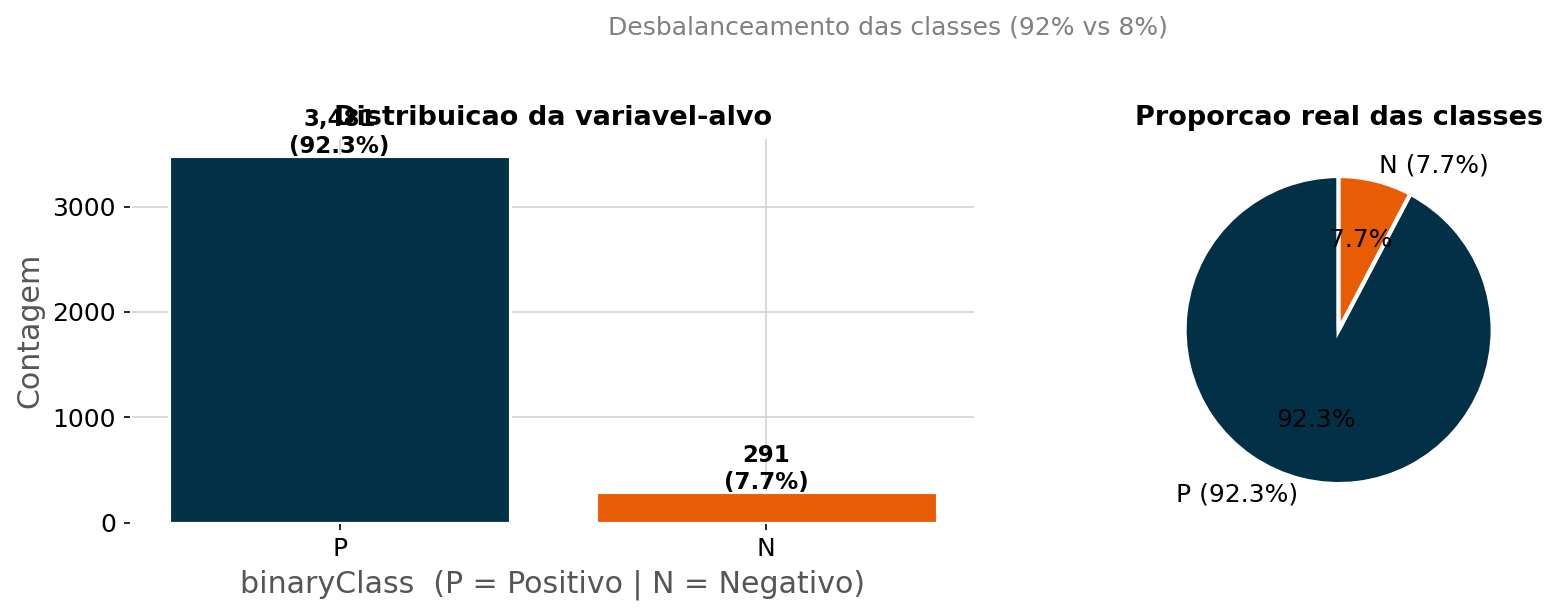

Classe majoritaria (P): 3,481 (92.3%)
Classe minoritaria (N): 291 (7.7%)
Razao de desbalanceamento: 12:1


In [5]:
# visualizacao do desbalanceamento das classes
counts = df['binaryClass'].value_counts()
pct    = df['binaryClass'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# grafico de barras da distribuicao bruta
axes[0].bar(counts.index, counts.values,
            color=[color_palette[0], color_palette[1]],
            edgecolor='white', linewidth=1.5)
for i, (val, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, val + 30, f'{val:,}\n({p:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribuicao da variavel-alvo', fontsize=13, fontweight='bold')
axes[0].set_xlabel('binaryClass  (P = Positivo | N = Negativo)')
axes[0].set_ylabel('Contagem')

# grafico de pizza da proporcao real
axes[1].pie(counts.values,
            labels=[f'{l} ({p:.1f}%)' for l, p in zip(counts.index, pct.values)],
            colors=[color_palette[0], color_palette[1]],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporcao real das classes', fontsize=13, fontweight='bold')

plt.suptitle('Desbalanceamento das classes (92% vs 8%)',
             fontsize=12, color='gray', y=1.02)
plt.tight_layout()
plt.show()

print(f'Classe majoritaria (P): {counts["P"]:,} ({pct["P"]:.1f}%)')
print(f'Classe minoritaria (N): {counts["N"]:,} ({pct["N"]:.1f}%)')
print(f'Razao de desbalanceamento: {counts["P"]/counts["N"]:.0f}:1')


> Por que analisar o desbalanceamento de classes?
>
> A distribuição da variável-alvo é uma das primeiras coisas a verificar em qualquer problema de classificação. Um dataset **severamente desbalanceado** (92% Positivo vs. 8% Negativo) faz com que modelos "preguiçosos" obtenham alta acurácia simplesmente prevendo sempre a classe majoritária — sem aprender nada de útil. Identificar esse problema aqui nos guia nas decisões seguintes: uso de `class_weight='balanced'`, métricas de avaliação adequadas (Recall e F1, não Acurácia) e possível aplicação de técnicas de reamostragem como SMOTE nas próximas versões.

### 2.3 Identificação de Valores Faltantes (`?`)

Colunas com valores faltantes:


,Faltantes,Percentual (%)
TBG,3772,100.00
T3,769,20.39
T4U,387,10.26
FTI,385,10.21
TSH,369,9.78
TT4,231,6.12
sex,150,3.98
age,1,0.03


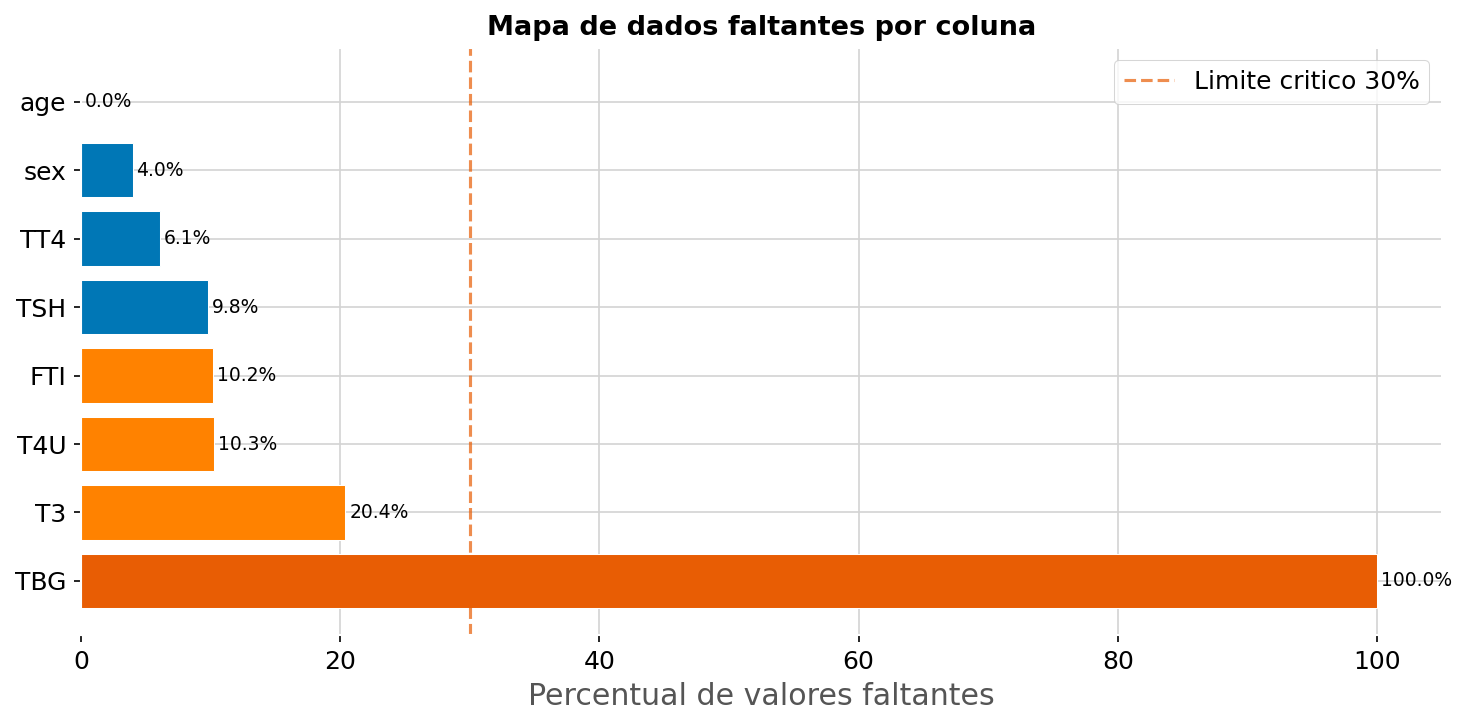

In [6]:
# mapeamento de valores faltantes: substituicao de '?' por NaN
df_raw     = df.replace('?', np.nan)
missing    = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df  = pd.DataFrame({'Faltantes': missing, 'Percentual (%)': missing_pct})
missing_df  = missing_df[missing_df['Faltantes'] > 0].sort_values('Percentual (%)', ascending=False)

print('Colunas com valores faltantes:')
display(missing_df)

# cores por nivel de criticidade: vermelho > 30%, laranja > 10%, azul restante
colors_miss = [color_palette[1] if p > 30 else color_palette[3] if p > 10 else color_palette[2]
               for p in missing_df['Percentual (%)']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['Percentual (%)'],
               color=colors_miss, edgecolor='white')
for bar, pct_val in zip(bars, missing_df['Percentual (%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{pct_val:.1f}%', va='center', fontsize=9)
ax.axvline(30, color=color_palette[1], linestyle='--', alpha=0.7, label='Limite critico 30%')
ax.set_xlabel('Percentual de valores faltantes')
ax.set_title('Mapa de dados faltantes por coluna', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


>  Por que mapear os valores faltantes antes de qualquer coisa?
>
> O dataset original usa `'?'` como marcador de ausência — o que não é reconhecido automaticamente pelo pandas. Convertê-los para `NaN` é essencial para que as funções de análise e imputação funcionem corretamente. Visualizar o percentual de missings por coluna permite tomar decisões informadas: colunas com mais de 70% de ausência (como `TBG`) são candidatas à remoção, enquanto colunas com ausência moderada podem ser imputadas. Ignorar este passo levaria a erros silenciosos nas etapas de modelagem.

### 2.4 Análise das Medidas Hormonais (TSH, T3, TT4, T4U, FTI)

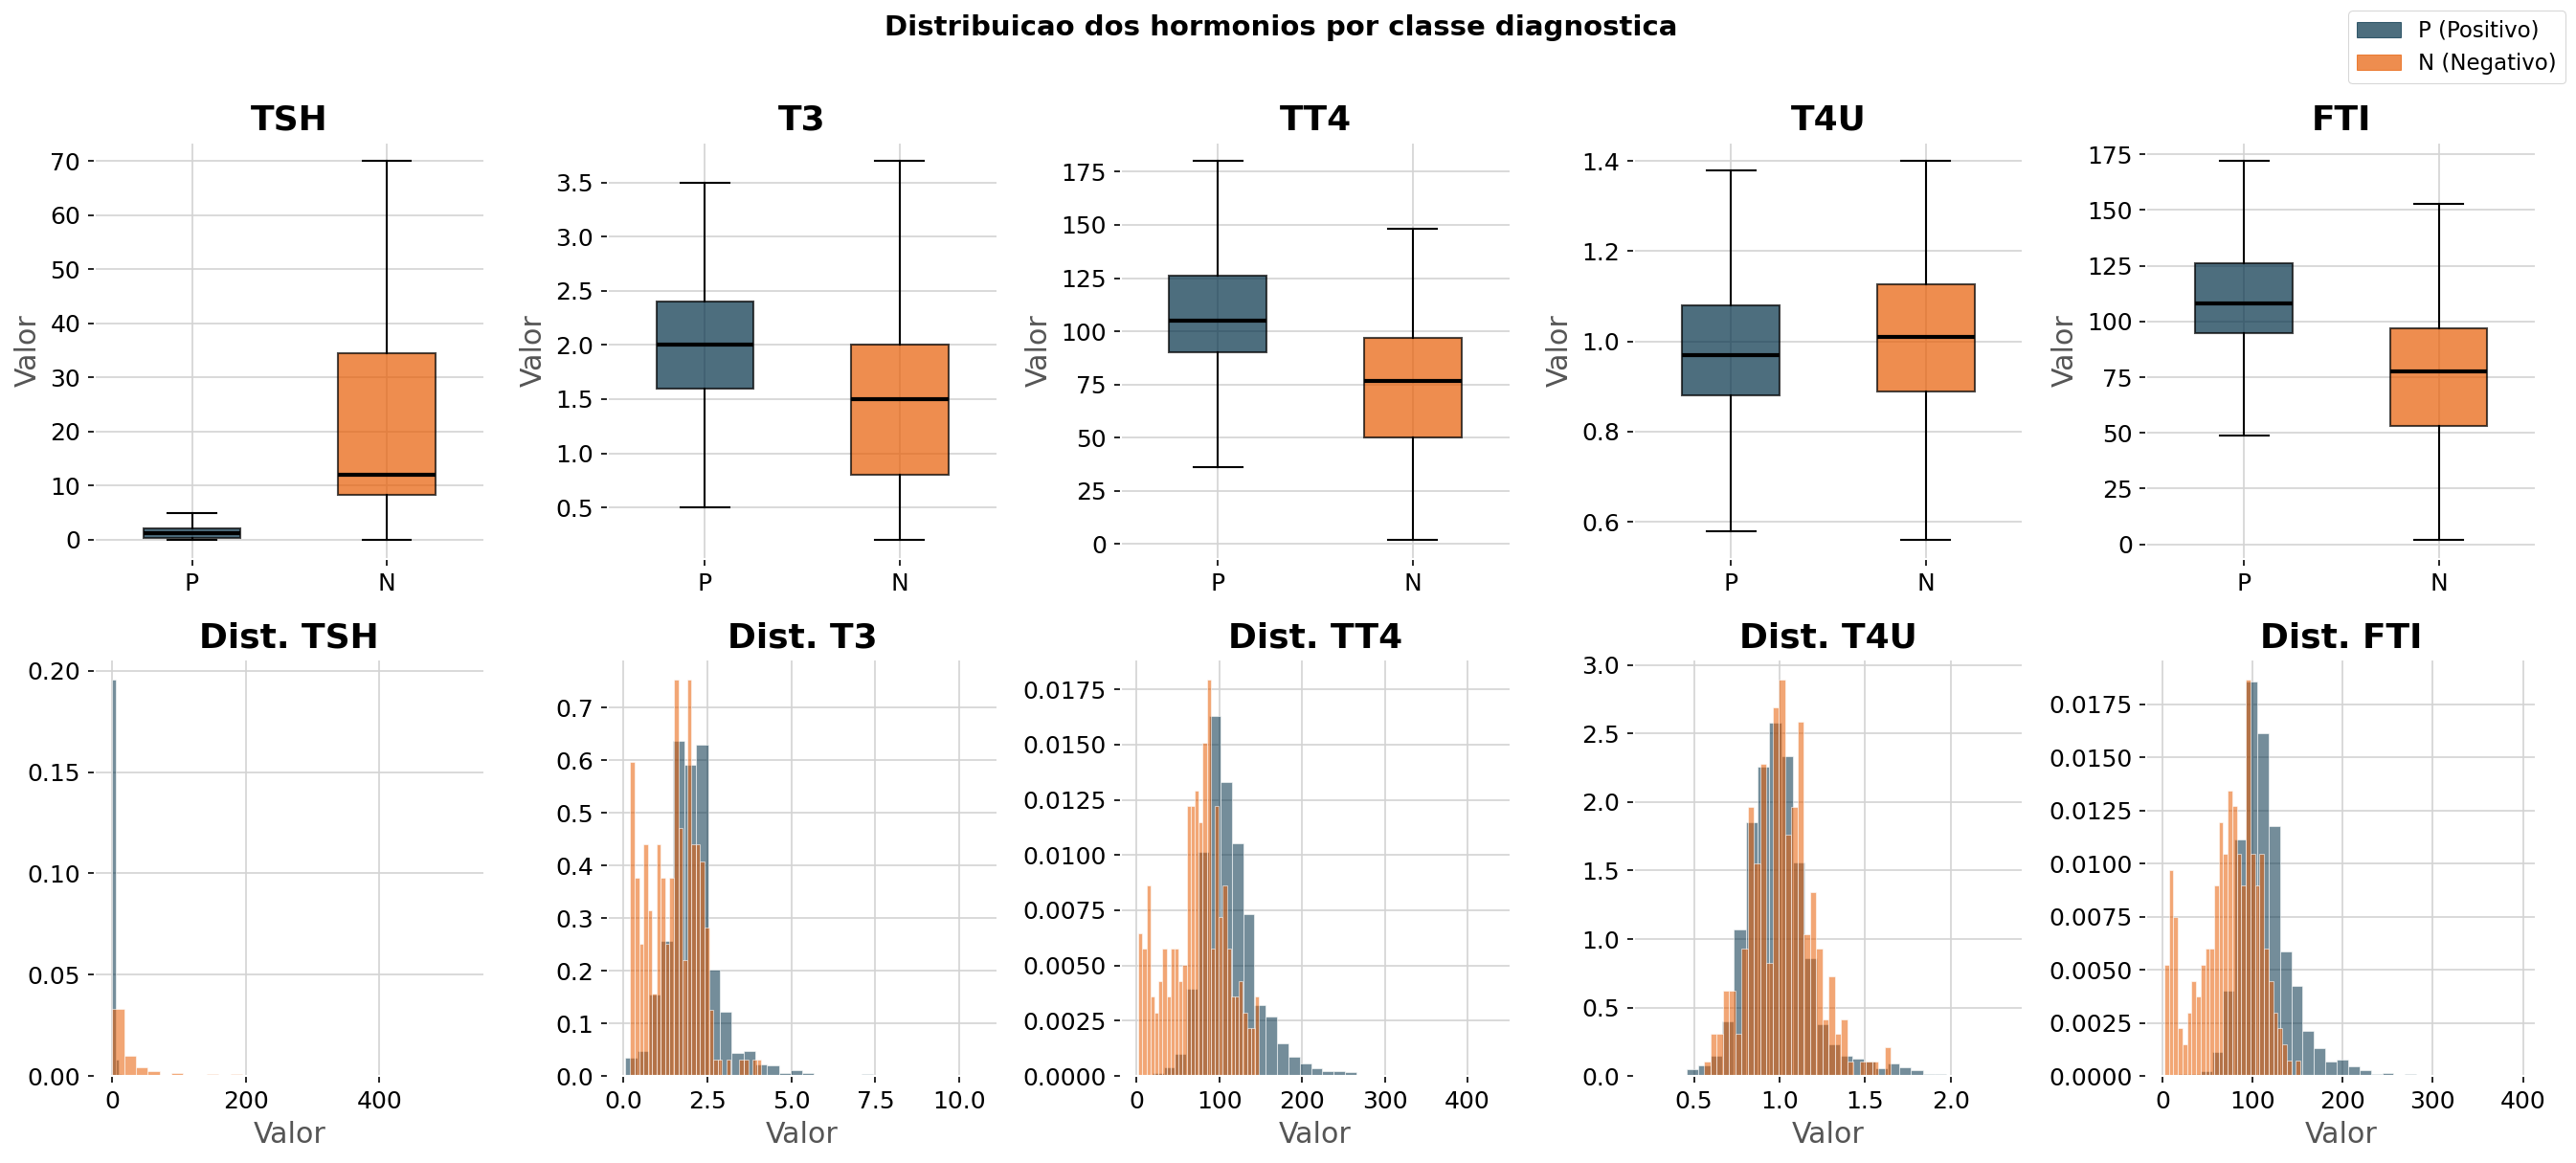

In [7]:
# distribuicao dos hormonios por classe diagnostica
hormones = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']

for col in hormones:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

palette = {'P': color_palette[0], 'N': color_palette[1]}

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, col in enumerate(hormones):
    # boxplot por classe
    for j, (cls, color) in enumerate(palette.items()):
        data_cls = df_raw[df_raw['binaryClass'] == cls][col].dropna()
        axes[0, i].boxplot(data_cls, positions=[j], widths=0.5,
                           patch_artist=True,
                           boxprops=dict(facecolor=color, alpha=0.7),
                           medianprops=dict(color='black', linewidth=2),
                           showfliers=False)
    axes[0, i].set_xticks([0, 1])
    axes[0, i].set_xticklabels(['P', 'N'])
    axes[0, i].set_title(col, fontweight='bold')
    axes[0, i].set_ylabel('Valor')

    # histograma de densidade por classe
    for cls, color in palette.items():
        data_cls = df_raw[df_raw['binaryClass'] == cls][col].dropna()
        axes[1, i].hist(data_cls, bins=30, alpha=0.55, color=color,
                        label=cls, density=True, edgecolor='white')
    axes[1, i].set_title(f'Dist. {col}', fontweight='bold')
    axes[1, i].set_xlabel('Valor')

patch_p = mpatches.Patch(color=color_palette[0], alpha=0.7, label='P (Positivo)')
patch_n = mpatches.Patch(color=color_palette[1], alpha=0.7, label='N (Negativo)')
fig.legend(handles=[patch_p, patch_n], loc='upper right', fontsize=11)
fig.suptitle('Distribuicao dos hormonios por classe diagnostica',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


> Por que analisar os hormônios separados por classe diagnóstica?
>
> As medidas hormonais (TSH, T3, TT4, T4U, FTI) são o coração clínico do diagnóstico de hipotiroidismo. Ao plotar boxplots e histogramas **separados por classe** (Positivo vs. Negativo), estamos verificando se essas variáveis possuem **poder discriminativo** ou seja, se os valores diferem significativamente entre pacientes doentes e saudáveis. Se não houvesse separação visual entre as distribuições, esses atributos teriam baixo valor preditivo. Esta análise antecipa o que o SHAP confirmará na fase de avaliação: **TSH é o principal sinal clínico**.

### 2.5 Correlação entre Medidas Hormonais

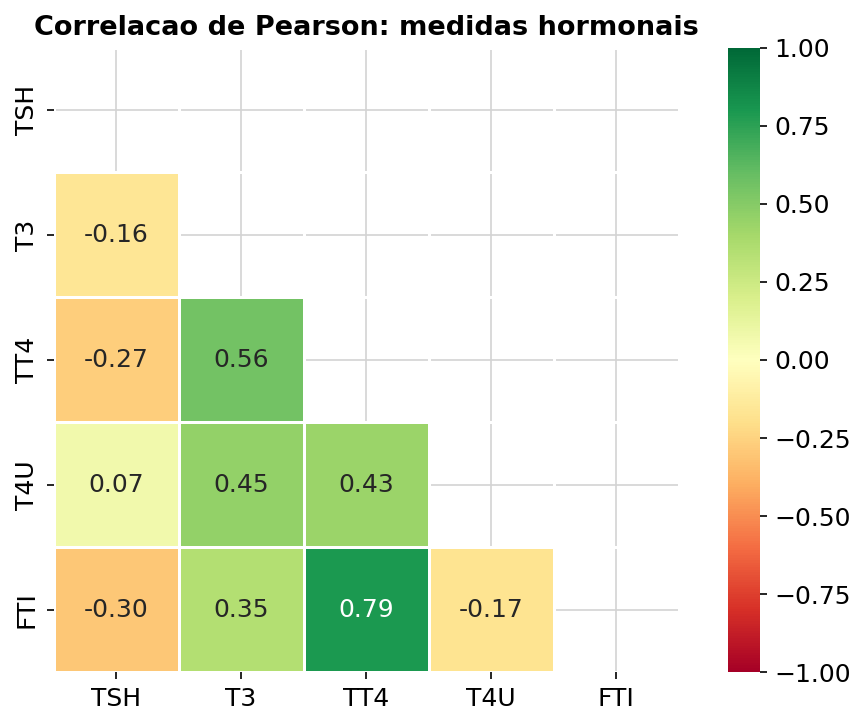

TT4 e FTI apresentam alta correlacao positiva (FTI e calculado a partir do TT4).
TSH elevado tende a indicar hipotiroidismo.


In [8]:
# correlacao de pearson entre as medidas hormonais
corr_matrix = df_raw[hormones].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white', square=True)
ax.set_title('Correlacao de Pearson: medidas hormonais', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('TT4 e FTI apresentam alta correlacao positiva (FTI e calculado a partir do TT4).')
print('TSH elevado tende a indicar hipotiroidismo.')


>  Para que serve a matriz de correlação aqui?
>
> Variáveis altamente correlacionadas carregam informação redundante. Identificar que `TT4` e `FTI` têm alta correlação (o FTI é calculado a partir do TT4) nos avisa que incluir ambas pode introduzir **multicolinearidade** — especialmente problemática para a Regressão Logística. Modelos baseados em árvores (Random Forest, LightGBM, XGBoost) são naturalmente mais robustos a isso, mas a informação ainda é útil para interpretabilidade e possível engenharia de features futura.

### 2.6 Perfil do Paciente: Idade, Sexo e Gravidez

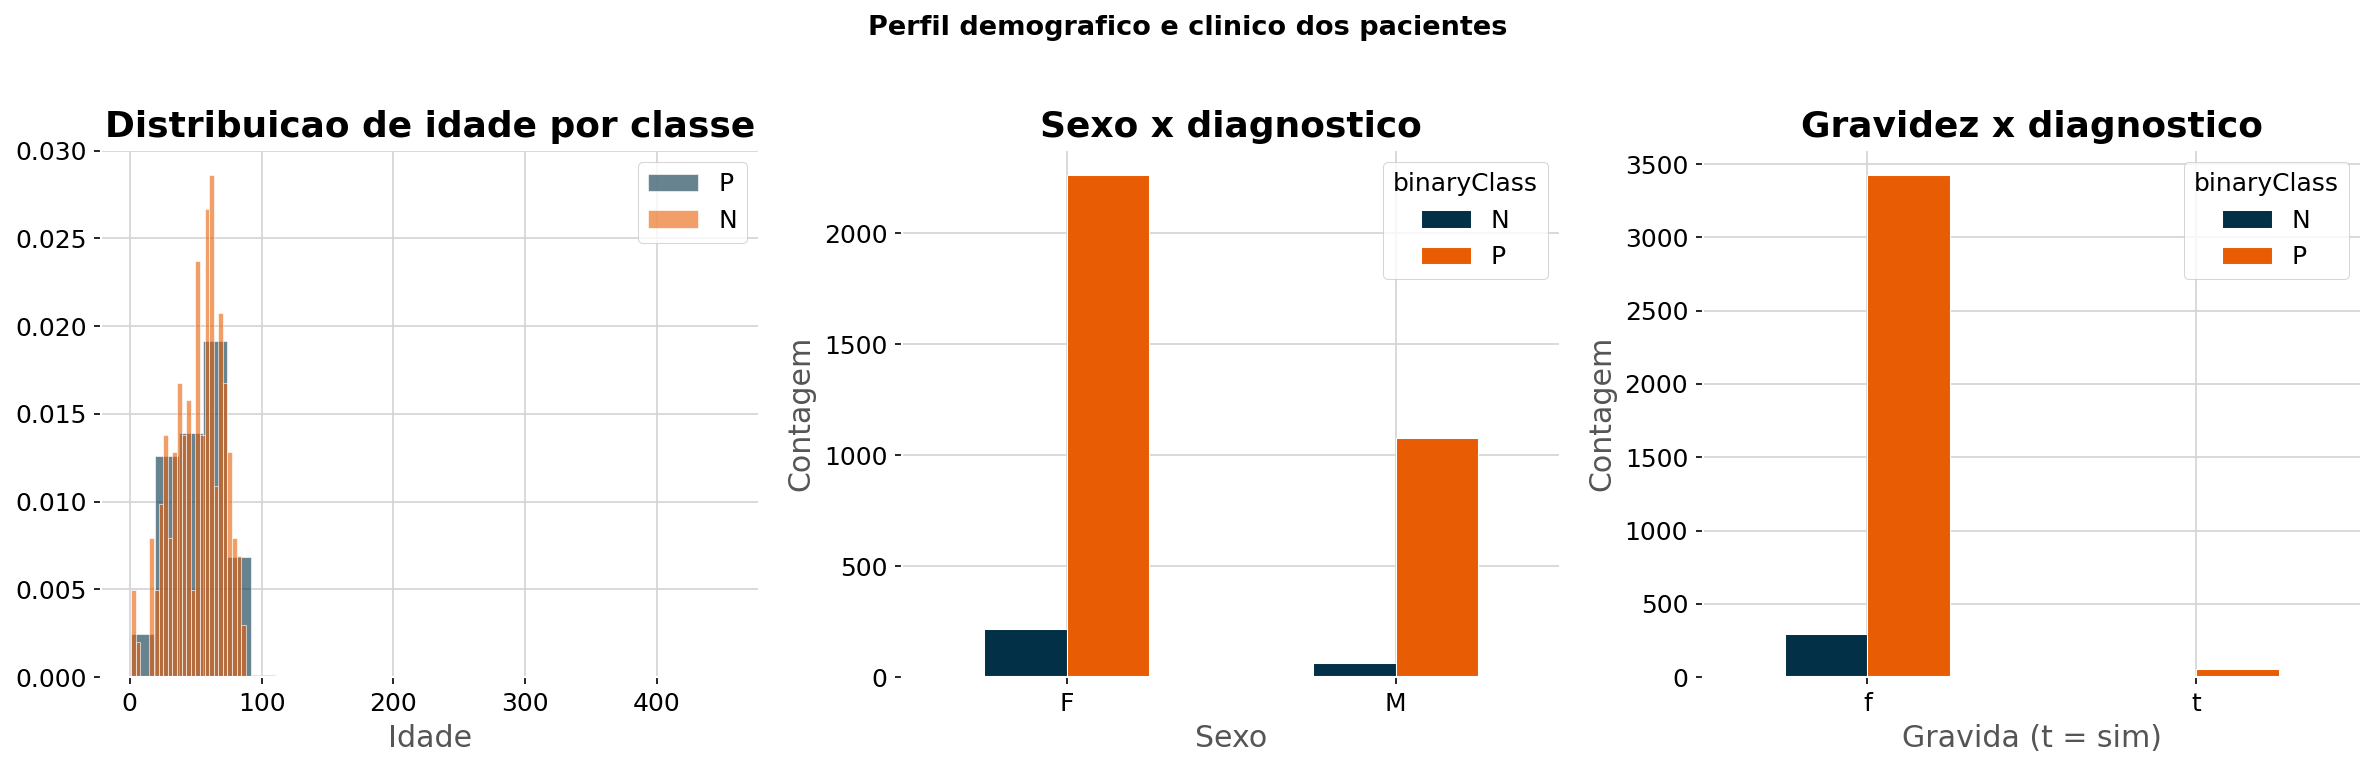

In [9]:
# perfil demografico e clinico dos pacientes
df_raw['age'] = pd.to_numeric(df_raw['age'], errors='coerce')

palette = {'P': color_palette[0], 'N': color_palette[1]}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# distribuicao de idade por classe
for cls, color in palette.items():
    d = df_raw[df_raw['binaryClass'] == cls]['age'].dropna()
    axes[0].hist(d, bins=25, alpha=0.6, color=color, label=cls,
                 density=True, edgecolor='white')
axes[0].set_title('Distribuicao de idade por classe', fontweight='bold')
axes[0].set_xlabel('Idade')
axes[0].legend()

# sexo vs diagnostico
sex_counts = df_raw.groupby(['sex', 'binaryClass']).size().unstack(fill_value=0)
sex_counts.plot(kind='bar', ax=axes[1],
                color=[color_palette[0], color_palette[1]], edgecolor='white', rot=0)
axes[1].set_title('Sexo x diagnostico', fontweight='bold')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Contagem')

# gravidez vs diagnostico
preg_counts = df_raw.groupby(['pregnant', 'binaryClass']).size().unstack(fill_value=0)
preg_counts.plot(kind='bar', ax=axes[2],
                 color=[color_palette[0], color_palette[1]], edgecolor='white', rot=0)
axes[2].set_title('Gravidez x diagnostico', fontweight='bold')
axes[2].set_xlabel('Gravida (t = sim)')
axes[2].set_ylabel('Contagem')

plt.suptitle('Perfil demografico e clinico dos pacientes',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


> Por que analisar o perfil demográfico?
>
> Variáveis como **idade**, **sexo** e **gravidez** são fatores de risco conhecidos para doenças da tireoide. O hipotiroidismo é mais prevalente em mulheres e sua incidência aumenta com a idade. A gravidez também é um período de maior risco hormonal. Incluir essa análise no EDA: (1) valida se o dataset reflete o conhecimento clínico, (2) confirma que essas variáveis têm potencial preditivo e merecem estar no modelo, e (3) identifica possíveis vieses de seleção amostral que poderiam afetar a generalização do modelo.

---
## 3. Preparação dos Dados

### 3.1 Limpeza e Conversão de  `?`  para NaN e Tipagem

In [10]:
# copia limpa do dataframe com tipagem correta das colunas numericas
df_clean = df.copy().replace('?', np.nan)

num_cols = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']
for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print('Tipos apos conversao:')
print(df_clean[num_cols].dtypes)
print()
print(f'Shape: {df_clean.shape}')


Tipos apos conversao:
age    float64
TSH    float64
T3     float64
TT4    float64
T4U    float64
FTI    float64
TBG    float64
dtype: object

Shape: (3772, 30)


> Por que criar uma cópia limpa do DataFrame?
>
> Trabalhar sempre em uma cópia (`df.copy()`) é uma prática defensiva fundamental: preserva o dataset original intacto para que possamos rever ou reprocessar dados sem precisar recarregar o arquivo. A conversão de `'?'` para `NaN` e a tipagem explícita das colunas numéricas são passos obrigatórios — o pandas lê colunas com valores mistos (números + `'?'`) como `object`, e operações como média e correlação só funcionam corretamente com tipos numéricos reais.

### 3.2 Análise de Outliers nos Hormônios

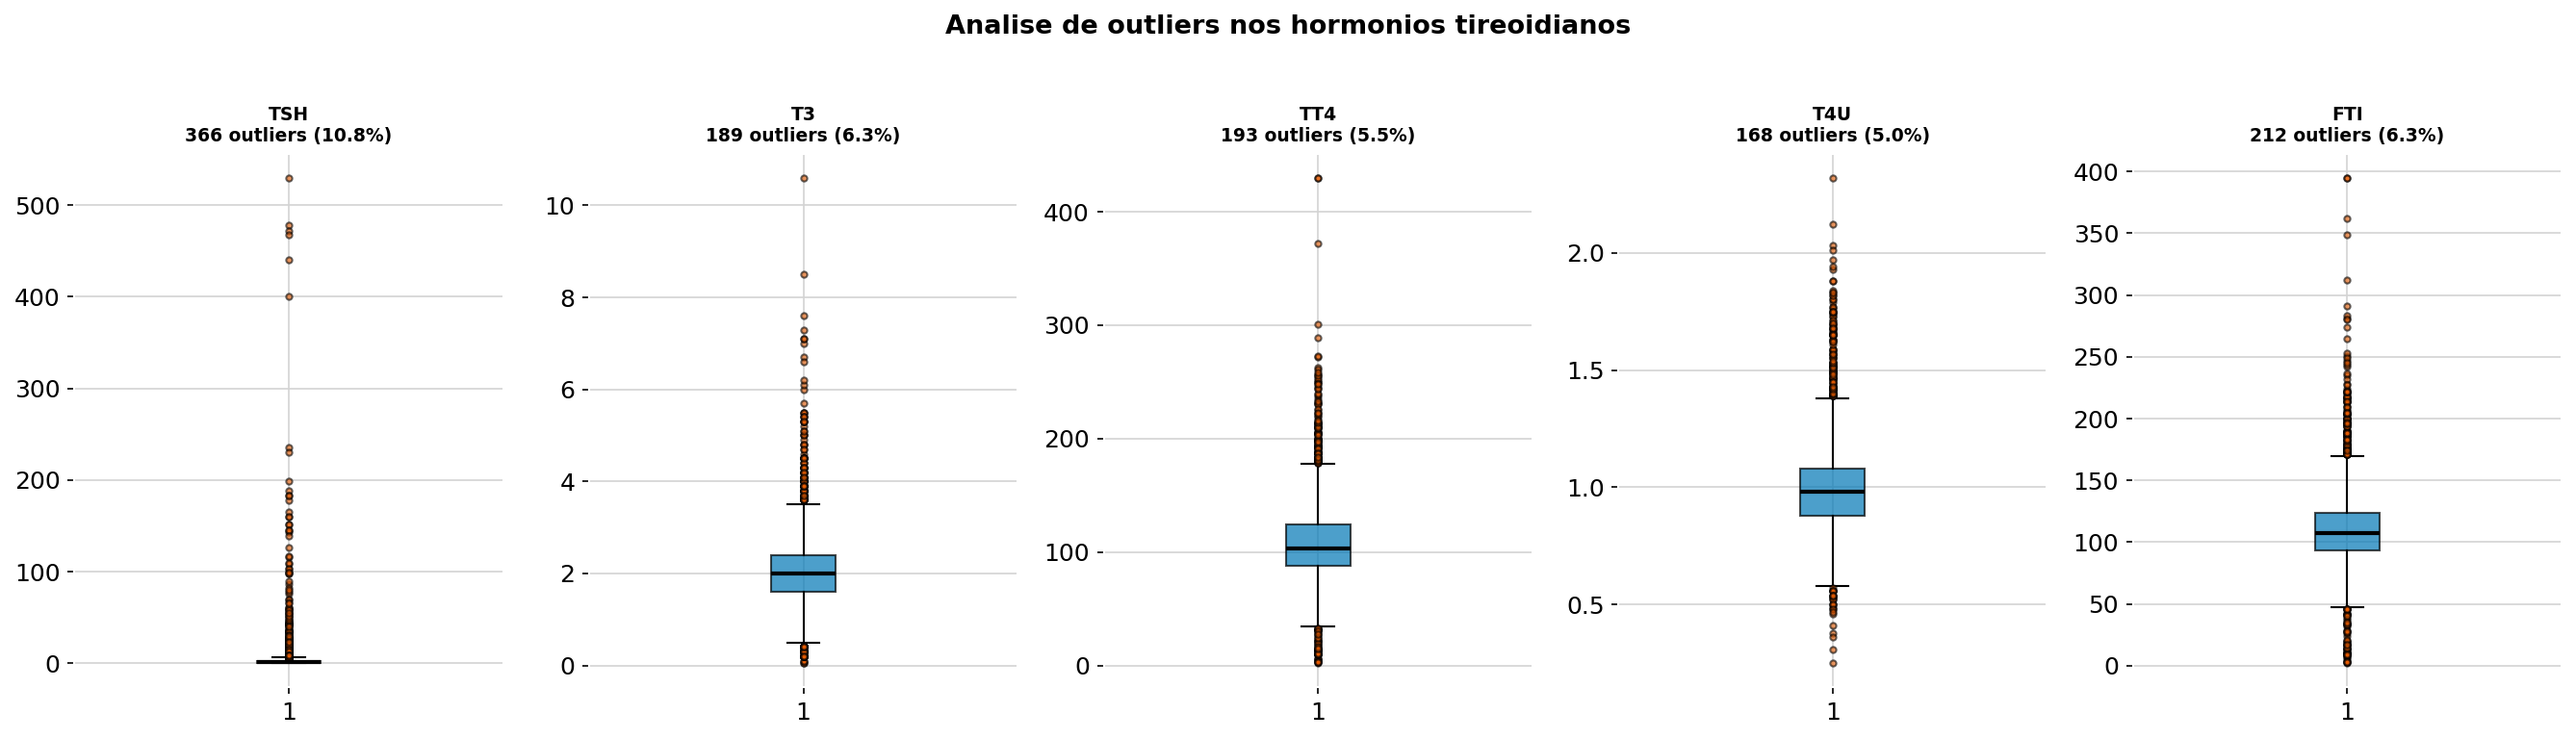

Valores extremos de TSH sao clinicamente relevantes e serao mantidos.
Idades acima de 100 anos serao tratadas como erro de digitacao.

Idades > 100: 1 registros substituidos por NaN


In [11]:
# analise de outliers nos hormonios via boxplot com contagem por IQR
hormones = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']  # redefinido para garantir escopo sobre df_clean

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(hormones):
    d        = df_clean[col].dropna()
    q1, q3   = d.quantile(0.25), d.quantile(0.75)
    iqr      = q3 - q1
    outliers = d[(d < q1 - 1.5 * iqr) | (d > q3 + 1.5 * iqr)]

    axes[i].boxplot(d, patch_artist=True,
                    boxprops=dict(facecolor=color_palette[2], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor=color_palette[1],
                                    markersize=3, alpha=0.6))
    axes[i].set_title(
        f'{col}\n{len(outliers)} outliers ({len(outliers)/len(d)*100:.1f}%)',
        fontweight='bold', fontsize=9)

plt.suptitle('Analise de outliers nos hormonios tireoidianos',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Valores extremos de TSH sao clinicamente relevantes e serao mantidos.')
print('Idades acima de 100 anos serao tratadas como erro de digitacao.')

# trata idades improvaveis
print(f'\nIdades > 100: {(df_clean["age"] > 100).sum()} registros substituidos por NaN')
df_clean.loc[df_clean['age'] > 100, 'age'] = np.nan


> Por que analisar outliers mas não removê-los?
>
> Em dados clínicos, outliers nem sempre são erros — frequentemente são o **sinal mais importante**. Um TSH extremamente elevado, por exemplo, é exatamente o que caracteriza o hipotiroidismo severo: removê-lo seria apagar a evidência mais valiosa para o modelo. A decisão técnica adotada foi **manter os outliers hormonais** (preservando o sinal clínico) e tratar apenas idades biologicamente impossíveis (> 100 anos), que são claramente erros de digitação. Esta é a diferença entre uma abordagem estatística cega e uma abordagem orientada pelo domínio do negócio.

### 3.3 Codificação das Variáveis

In [12]:
# encoding das variaveis categoricas e booleanas

# colunas booleanas: f/t para 0/1
bool_cols = [
    'on thyroxine', 'query on thyroxine', 'on antithyroid medication',
    'sick', 'pregnant', 'thyroid surgery', 'I131 treatment',
    'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre',
    'tumor', 'hypopituitary', 'psych',
    'TSH measured', 'T3 measured', 'TT4 measured', 'T4U measured',
    'FTI measured', 'TBG measured'
]
for col in bool_cols:
    df_clean[col] = df_clean[col].map({'t': 1, 'f': 0})

# sexo: F/M para 0/1
df_clean['sex'] = df_clean['sex'].map({'F': 0, 'M': 1})

# referral source: label encoding (variavel nominal sem ordem)
le = LabelEncoder()
df_clean['referral source'] = le.fit_transform(df_clean['referral source'].fillna('unknown'))
print('Categorias referral source:', le.classes_)

# target: P = 1 (hipotiroidismo), N = 0 (saudavel)
df_clean['binaryClass'] = df_clean['binaryClass'].map({'P': 1, 'N': 0})

print('\nEncoding concluido')
df_clean.head(3)


Categorias referral source: ['STMW' 'SVHC' 'SVHD' 'SVI' 'other']

Encoding concluido


,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41.0,0.0,0,0,0,0,0,0,0,0,...,1,125.0,1,1.14,1,109.0,0,NaN,1,1
1,23.0,0.0,0,0,0,0,0,0,0,0,...,1,102.0,0,NaN,0,NaN,0,NaN,4,1
2,46.0,1.0,0,0,0,0,0,0,0,0,...,1,109.0,1,0.91,1,120.0,0,NaN,4,1


> Por que codificar variáveis categóricas e booleanas?
>
> Algoritmos de machine learning trabalham exclusivamente com números. As variáveis booleanas (`'t'`/`'f'`) são convertidas para `1`/`0`, mantendo a semântica binária. O sexo (`'F'`/`'M'`) também recebe codificação binária. Para `referral source` (variável com múltiplas categorias nominais sem ordem), usamos `LabelEncoder` — uma abordagem simples que funciona bem para modelos baseados em árvores, que não assumem ordenação. Em modelos lineares, preferiríamos `OneHotEncoding` para evitar a interpretação de ordem implícita.

### 3.4 Imputação de Valores Faltantes

In [13]:
# separacao de features e target; remocao de colunas com alto percentual de ausencia
X = df_clean.drop(columns='binaryClass')
y = df_clean['binaryClass']

# calcula missing sobre X (sem o target) para nao contaminar o calculo
high_missing = X.isnull().mean()
cols_to_drop = high_missing[high_missing > 0.70].index.tolist()
print(f'Colunas removidas (>70% missing): {cols_to_drop}')
X = X.drop(columns=cols_to_drop)

print(f'Shape apos remocao: {X.shape}')
print(f'Missing em X: {X.isnull().sum().sum()} valores a serem imputados apos o split')


Colunas removidas (>70% missing): ['TBG']
Shape apos remocao: (3772, 28)
Missing em X: 2293 valores a serem imputados apos o split


> Como decidimos a estratégia de imputação?
>
> Não existe estratégia única ideal, a escolha depende do tipo e do volume de dados faltantes. Colunas com mais de 70% de ausência foram **removidas**: imputar a maioria dos valores criaria informação artificial que distorceria o aprendizado. Para as demais, usamos **mediana** nas variáveis numéricas (robusta a outliers, diferente da média) e **moda** nas categóricas/booleanas. A imputação sempre é feita **após** o split treino/teste para evitar data leakage, o modelo não deve "ver" informações do conjunto de teste durante o preprocessamento.

### 3.5 Split Treino / Teste

In [14]:
# divisao treino/teste com estratificacao para preservar proporcao das classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Treino: {X_train.shape[0]:,} amostras  |  Teste: {X_test.shape[0]:,} amostras')
print(f'Proporcao de positivos: Treino {y_train.mean():.3f} | Teste {y_test.mean():.3f}')

# imputacao feita APOS o split para evitar data leakage
# fit apenas no treino; transform aplicado separadamente em treino e teste
num_cols_imp = [c for c in X_train.columns if X_train[c].dtype in ['float64', 'int64']]
cat_cols_imp = [c for c in X_train.columns if X_train[c].dtype == 'object']

imp_num = SimpleImputer(strategy='median')
imp_cat = SimpleImputer(strategy='most_frequent')

X_train[num_cols_imp] = imp_num.fit_transform(X_train[num_cols_imp])
X_test[num_cols_imp]  = imp_num.transform(X_test[num_cols_imp])

if cat_cols_imp:
    X_train[cat_cols_imp] = imp_cat.fit_transform(X_train[cat_cols_imp])
    X_test[cat_cols_imp]  = imp_cat.transform(X_test[cat_cols_imp])

print(f'\nFaltantes apos imputacao: treino={X_train.isnull().sum().sum()} | teste={X_test.isnull().sum().sum()}')


Treino: 3,017 amostras  |  Teste: 755 amostras
Proporcao de positivos: Treino 0.923 | Teste 0.923

Faltantes apos imputacao: treino=0 | teste=0


> Por que usar `stratify=y` no split?
>
> Com um dataset desbalanceado (92%/8%), um split aleatório simples pode — por azar estatístico — concentrar quase todos os casos positivos no treino ou no teste, tornando a avaliação enganosa. O parâmetro `stratify=y` garante que **ambos os conjuntos mantenham a mesma proporção de classes** do dataset original, tornando a avaliação no teste um reflexo fiel do desempenho real do modelo em produção.


## 4. Modelagem

### 4.1 Regressão Logística

In [15]:
# baseline com regressao logistica e class_weight=balanced
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
print('BASELINE: Regressao Logistica')
print(classification_report(y_test, y_pred_lr, target_names=['Negativo (N)', 'Positivo (P)']))
print(f'AUC-ROC: {roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1]):.4f}')


BASELINE: Regressao Logistica
              precision    recall  f1-score   support

Negativo (N)       0.79      0.97      0.87        58
Positivo (P)       1.00      0.98      0.99       697

    accuracy                           0.98       755
   macro avg       0.89      0.97      0.93       755
weighted avg       0.98      0.98      0.98       755

AUC-ROC: 0.9937


> Por que começar com uma Regressão Logística como baseline?
>
> O baseline tem uma função fundamental: **estabelecer um piso de desempenho** que qualquer modelo mais complexo precisa superar para justificar sua complexidade adicional. A Regressão Logística é interpretável, rápida e bem-compreendida, se ela já alcançar métricas satisfatórias, não há necessidade de recorrer a modelos mais pesados. O parâmetro `class_weight='balanced'` ajusta automaticamente os pesos das classes inversamente proporcionais à sua frequência, compensando o desbalanceamento sem precisar reamostrar os dados.

### 4.2 Validação Cruzada Estratificada K-Fold (k=5)

In [16]:
# cross-validation estratificado 5-fold para comparar os quatro modelos
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                   random_state=SEED, n_jobs=-1),
    'XGBoost'            : XGBClassifier(n_estimators=200,
                                          scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                                          random_state=SEED, eval_metric='logloss', verbosity=0),
    'LightGBM'           : LGBMClassifier(n_estimators=200, class_weight='balanced',
                                           random_state=SEED, verbose=-1)
}

scoring    = ['recall', 'f1', 'roc_auc', 'precision']
cv_results = {}

print('Rodando Cross-Validation (5-Fold)...')
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'Recall'   : scores['test_recall'].mean(),
        'F1-Score' : scores['test_f1'].mean(),
        'AUC-ROC'  : scores['test_roc_auc'].mean(),
        'Precision': scores['test_precision'].mean()
    }
    print(f'  {name}: OK')

cv_df = pd.DataFrame(cv_results).T.round(4)
print('\nResultados Cross-Validation (media 5-Fold):')
display(cv_df.style.highlight_max(axis=0, color='#d5f5e3').highlight_min(axis=0, color='#fadbd8'))


Rodando Cross-Validation (5-Fold)...
  Logistic Regression: OK
  Random Forest: OK
  XGBoost: OK
  LightGBM: OK

Resultados Cross-Validation (media 5-Fold):


,Recall,F1-Score,AUC-ROC,Precision
Logistic Regression,0.968800,0.982900,0.990000,0.997400
Random Forest,0.996000,0.996900,0.999300,0.997800
XGBoost,0.988500,0.993700,0.996600,0.998900
LightGBM,0.996400,0.997300,0.998700,0.998200


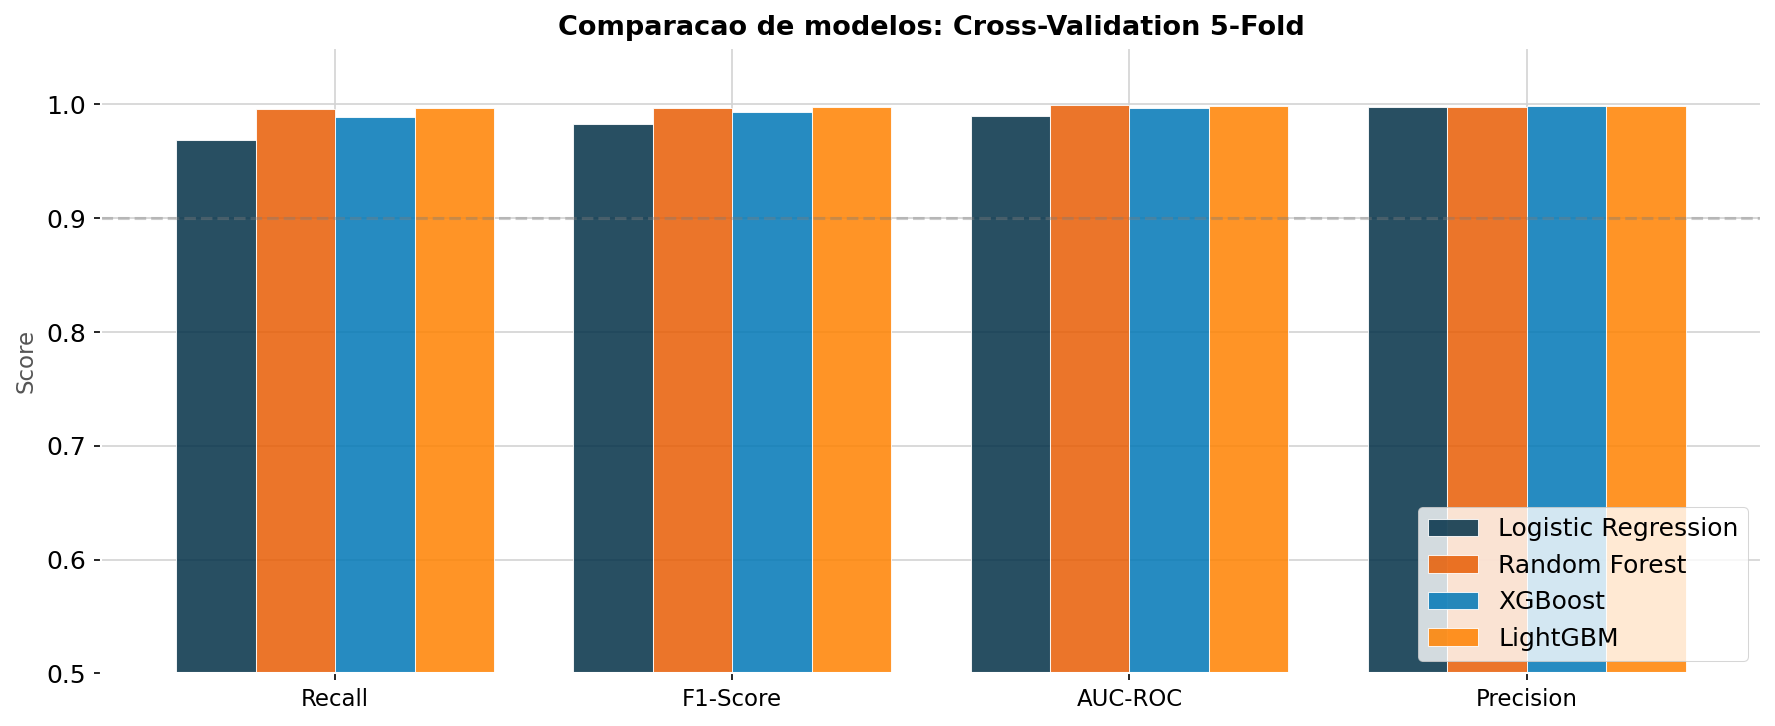

In [17]:
# comparacao visual das metricas de cross-validation por modelo
x         = np.arange(len(cv_df.columns))
width     = 0.2
colors_cv = [color_palette[0], color_palette[1], color_palette[2], color_palette[3]]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, row) in enumerate(cv_df.iterrows()):
    ax.bar(x + i * width, row.values, width,
           label=model_name, color=colors_cv[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(cv_df.columns, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Comparacao de modelos: Cross-Validation 5-Fold',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.05)
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


> Por que usar validação cruzada estratificada (K-Fold, k=5)?
>
> Avaliar um modelo em um único split treino/teste pode produzir resultados instáveis, bons ou ruins por acaso. A **validação cruzada com k=5** divide o treino em 5 partes, treina em 4 e avalia na 5ª, repetindo o processo 5 vezes. O resultado é a **média e variância das métricas**, o que dá uma estimativa muito mais confiável do desempenho real. O `StratifiedKFold` garante que cada fold mantenha a proporção de classes, essencial com dados desbalanceados. Comparar os quatro modelos na mesma configuração permite escolher o melhor candidato para o ajuste de hiperparâmetros com base em evidências robustas, não em um único resultado.

### 4.3 Ajuste de Hiperparâmetros do LightGBM (Melhor Modelo)

In [18]:
# busca de hiperparametros do LightGBM com RandomizedSearchCV
param_grid_lgbm = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7, -1],
    'num_leaves'       : [20, 31, 50],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'subsample'        : [0.7, 0.8, 1.0],
    'min_child_samples': [10, 20, 30]
}

lgbm_base    = LGBMClassifier(class_weight='balanced', random_state=SEED, verbose=-1)
random_search = RandomizedSearchCV(
    lgbm_base, param_grid_lgbm, n_iter=40,
    scoring='f1', cv=cv,
    random_state=SEED, n_jobs=-1, verbose=0
)

print('Rodando RandomizedSearchCV para LightGBM...')
random_search.fit(X_train, y_train)

print('\nMelhores hiperparametros:')
for k, v in random_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMelhor F1-Score (CV): {random_search.best_score_:.4f}')

best_lgbm = random_search.best_estimator_


Rodando RandomizedSearchCV para LightGBM...

Melhores hiperparametros:
  subsample: 0.7
  num_leaves: 20
  n_estimators: 300
  min_child_samples: 30
  max_depth: 5
  learning_rate: 0.1

Melhor F1-Score (CV): 0.9977


> Por que `RandomizedSearchCV` e não `GridSearchCV`?
>
> O `GridSearchCV` testa **todas** as combinações possíveis de hiperparâmetros — o que com 6 parâmetros e múltiplos valores resultaria em centenas de fits. O `RandomizedSearchCV` com `n_iter=40` testa 40 combinações **aleatórias**, o que na prática encontra soluções igualmente boas em uma fração do tempo. A pesquisa demonstra empiricamente que exploração aleatória no espaço de hiperparâmetros é tão eficaz quanto busca exaustiva para a maioria dos problemas. O scoring escolhido foi `'f1'` para equilibrar precisão e recall durante a otimização.


## 5. Avaliação

### 5.1 Comparação Final no Conjunto de Teste

In [19]:
# treinamento final de rf e xgb; lr e best_lgbm ja estavam treinados nas etapas anteriores
rf_model  = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                    random_state=SEED, n_jobs=-1)
xgb_model = XGBClassifier(n_estimators=200,
                           scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                           random_state=SEED, eval_metric='logloss', verbosity=0)

rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# lr: treinado na celula de baseline (X_train_sc)
# best_lgbm: best_estimator_ do RandomizedSearchCV, ja fittado com refit=True (padrao)
final_models = {
    'Logistic Regression': (lr, X_test_sc),
    'Random Forest'      : (rf_model, X_test),
    'XGBoost'            : (xgb_model, X_test),
    'LightGBM (tuned)'   : (best_lgbm, X_test)
}

results_test = []
for name, (model, X_t) in final_models.items():
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:, 1]
    results_test.append({
        'Modelo'   : name,
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'AUC-ROC'  : roc_auc_score(y_test, y_prob),
        'Precision': precision_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results_test).set_index('Modelo').round(4)
print('Metricas no conjunto de teste:')
display(results_df.style.highlight_max(axis=0, color='#d5f5e3').format('{:.4f}'))


Metricas no conjunto de teste:


,Recall,F1-Score,AUC-ROC,Precision
Modelo,,,,
Logistic Regression,0.9785,0.9877,0.9937,0.9971
Random Forest,0.9986,0.9993,1.0000,1.0000
XGBoost,0.9928,0.9964,0.9983,1.0000
LightGBM (tuned),0.9986,0.9993,1.0000,1.0000


> Por que reavaliar todos os modelos no conjunto de teste ao final?
>
> O conjunto de teste é o "árbitro final", dados que o modelo nunca viu durante o treinamento ou a validação. Reavaliar todos os modelos nele garante uma comparação justa e sem viés de seleção. É importante ressaltar: a escolha do modelo vencedor deve ser feita **com base nos resultados de CV** (no treino), não nos resultados do teste. Usar o teste para selecionar o modelo e depois reportar suas métricas inflaria artificialmente o desempenho reportado — um erro comum chamado de **test set leakage**.

### 5.2 Matriz de Confusão do Modelo Campeão

Decomposicao da matriz de confusao:
  Verdadeiros Positivos (TP): 696  doentes corretamente identificados
  Verdadeiros Negativos (TN):  58  saudaveis corretamente identificados
  Falsos Negativos (FN):        1  doentes NAO detectados (custo alto)
  Falsos Positivos (FP):        0  saudaveis classificados como doentes


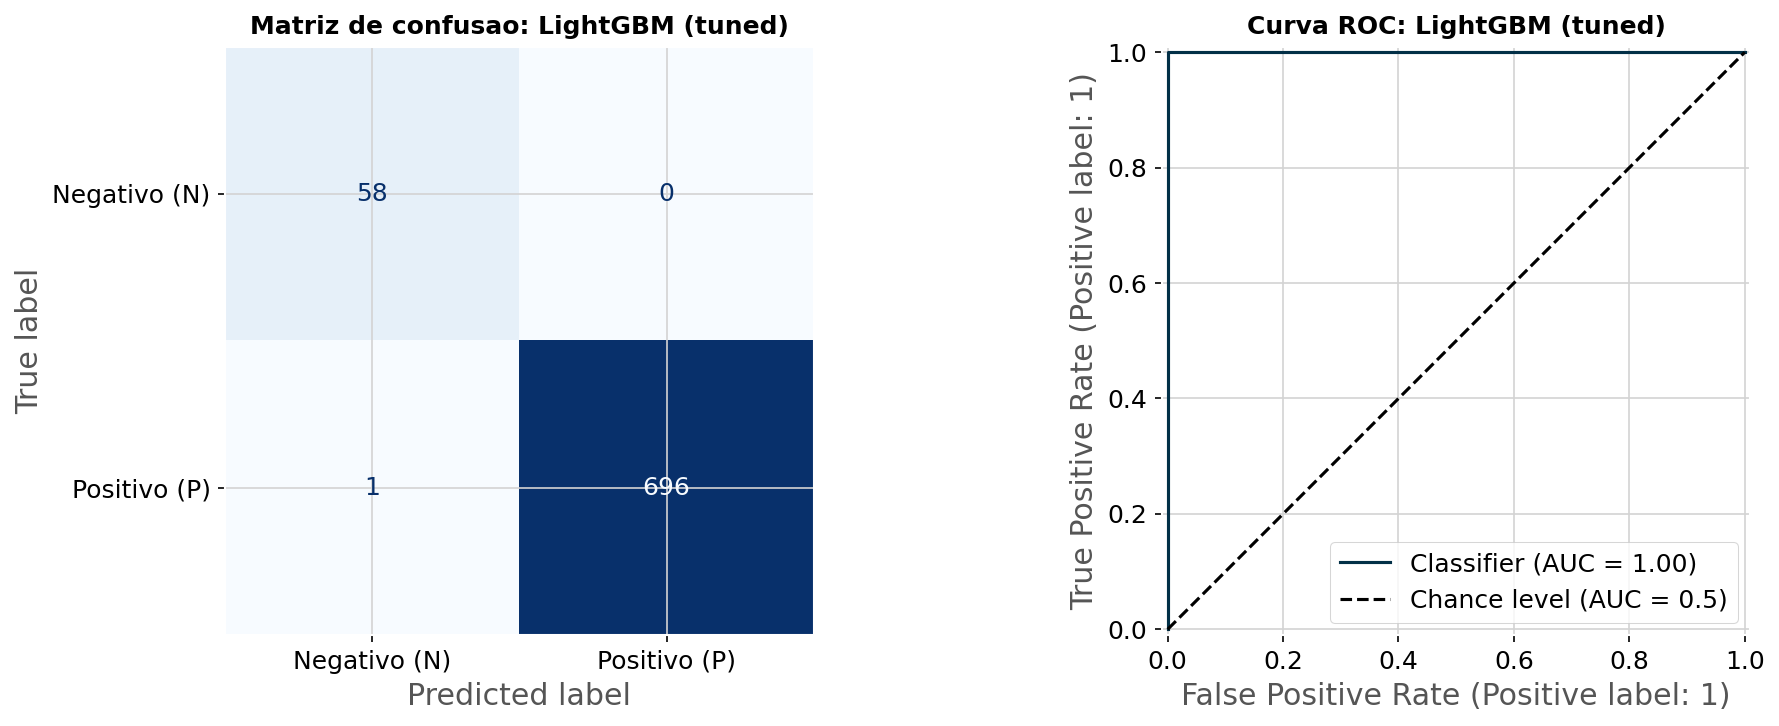


AUC-ROC: 1.0000

Relatorio completo:
              precision    recall  f1-score   support

Negativo (N)       0.98      1.00      0.99        58
Positivo (P)       1.00      1.00      1.00       697

    accuracy                           1.00       755
   macro avg       0.99      1.00      1.00       755
weighted avg       1.00      1.00      1.00       755



In [20]:
# matriz de confusao e curva ROC do modelo campeao LightGBM tuned
y_pred_best = best_lgbm.predict(X_test)
y_prob_best = best_lgbm.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# matriz de confusao
cm   = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negativo (N)', 'Positivo (P)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusao: LightGBM (tuned)', fontsize=12, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
print('Decomposicao da matriz de confusao:')
print(f'  Verdadeiros Positivos (TP): {tp:3d}  doentes corretamente identificados')
print(f'  Verdadeiros Negativos (TN): {tn:3d}  saudaveis corretamente identificados')
print(f'  Falsos Negativos (FN):      {fn:3d}  doentes NAO detectados (custo alto)')
print(f'  Falsos Positivos (FP):      {fp:3d}  saudaveis classificados como doentes')

# curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob_best, ax=axes[1],
                                  color=color_palette[0], plot_chance_level=True)
axes[1].set_title('Curva ROC: LightGBM (tuned)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nAUC-ROC: {roc_auc_score(y_test, y_prob_best):.4f}')
print('\nRelatorio completo:')
print(classification_report(y_test, y_pred_best, target_names=['Negativo (N)', 'Positivo (P)']))


> Como ler a matriz de confusão no contexto clínico?
>
> A matriz de confusão decompõe os erros do modelo em dois tipos bem distintos:
>
> - **Falsos Negativos (FN):** pacientes **doentes classificados como saudáveis** — o erro mais perigoso. Esses pacientes deixariam de receber tratamento, podendo desenvolver complicações graves.
> - **Falsos Positivos (FP):** pacientes **saudáveis classificados como doentes** — custo menor. Resultam em exames adicionais desnecessários, mas não em dano direto ao paciente.
>
> É por isso que **Recall (sensibilidade)** é a métrica principal: ela mede exatamente nossa capacidade de minimizar FN. Um modelo que prioriza Recall aceita ter mais FP para não deixar doentes sem diagnóstico.

### 5.3 Curvas ROC -- Comparação de Todos os Modelos

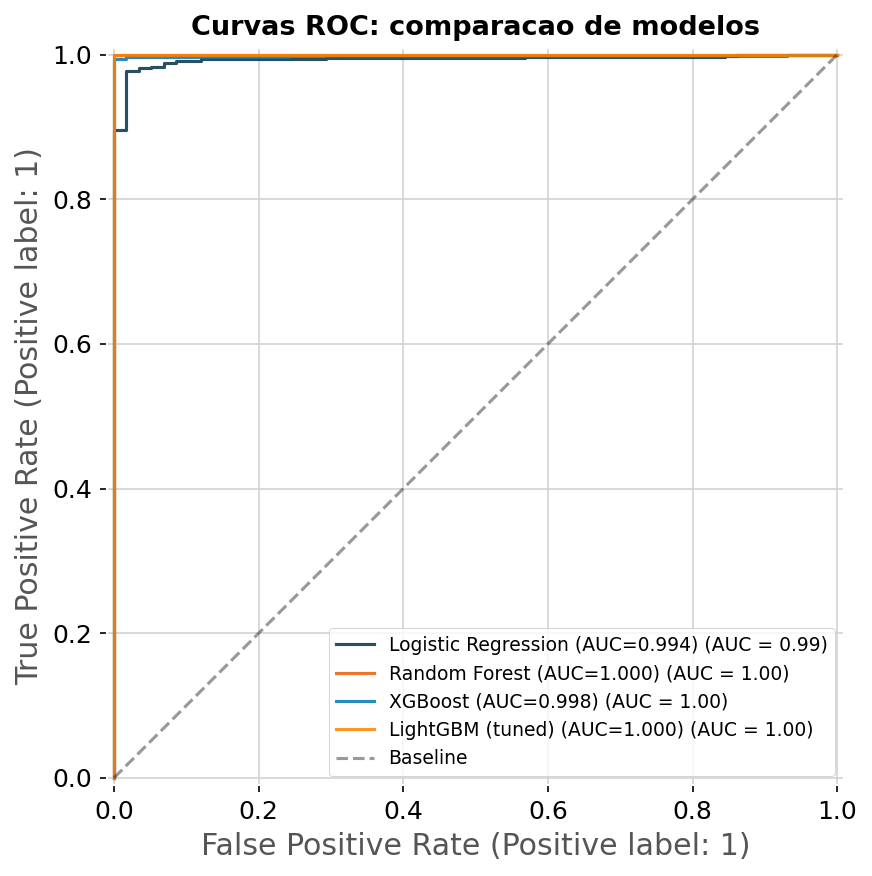

In [21]:
# curvas ROC comparativas para todos os modelos
fig, ax = plt.subplots(figsize=(8, 6))
roc_colors = [color_palette[0], color_palette[1], color_palette[2], color_palette[3]]

for (name, (model, X_t)), color in zip(final_models.items(), roc_colors):
    y_prob = model.predict_proba(X_t)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax,
                                     name=f'{name} (AUC={auc:.3f})',
                                     color=color, alpha=0.85)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Baseline')
ax.set_title('Curvas ROC: comparacao de modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


> O que a curva ROC revela além do AUC?
>
> A curva ROC plota a **Taxa de Verdadeiros Positivos (Recall)** contra a **Taxa de Falsos Positivos** para todos os possíveis limiares de classificação. O AUC (Área sob a Curva) resume isso em um único número: 0.5 = modelo aleatório, 1.0 = classificador perfeito. Comparar as curvas de todos os modelos no mesmo gráfico permite ver não só qual tem maior AUC, mas também como cada um se comporta em diferentes pontos de operação, útil para calibrar o limiar de decisão conforme a tolerância clínica a falsos positivos vs. falsos negativos.

### 5.4 Interpretabilidade com SHAP (XAI)

In [22]:
# calculo dos valores SHAP para o modelo LightGBM
print('Calculando valores SHAP...')

explainer   = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test)

# para classificacao binaria, SHAP retorna lista [classe0, classe1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print('SHAP calculado com sucesso')


Calculando valores SHAP...
SHAP calculado com sucesso


> O que é SHAP e por que é importante em contextos clínicos?
>
> **SHAP (SHapley Additive exPlanations)** é um método de explicabilidade baseado na teoria dos jogos que atribui a cada feature uma contribuição justa para cada previsão individual do modelo. Em contextos clínicos, interpretabilidade não é opcional, médicos precisam entender **por que** o modelo classificou um paciente como de alto risco para confiar e agir sobre a recomendação. Ao contrário de métricas globais de importância (como feature importance do Random Forest), o SHAP mostra a **direção** (positiva ou negativa) e a **magnitude** do impacto de cada variável, tanto globalmente quanto para cada paciente individualmente.

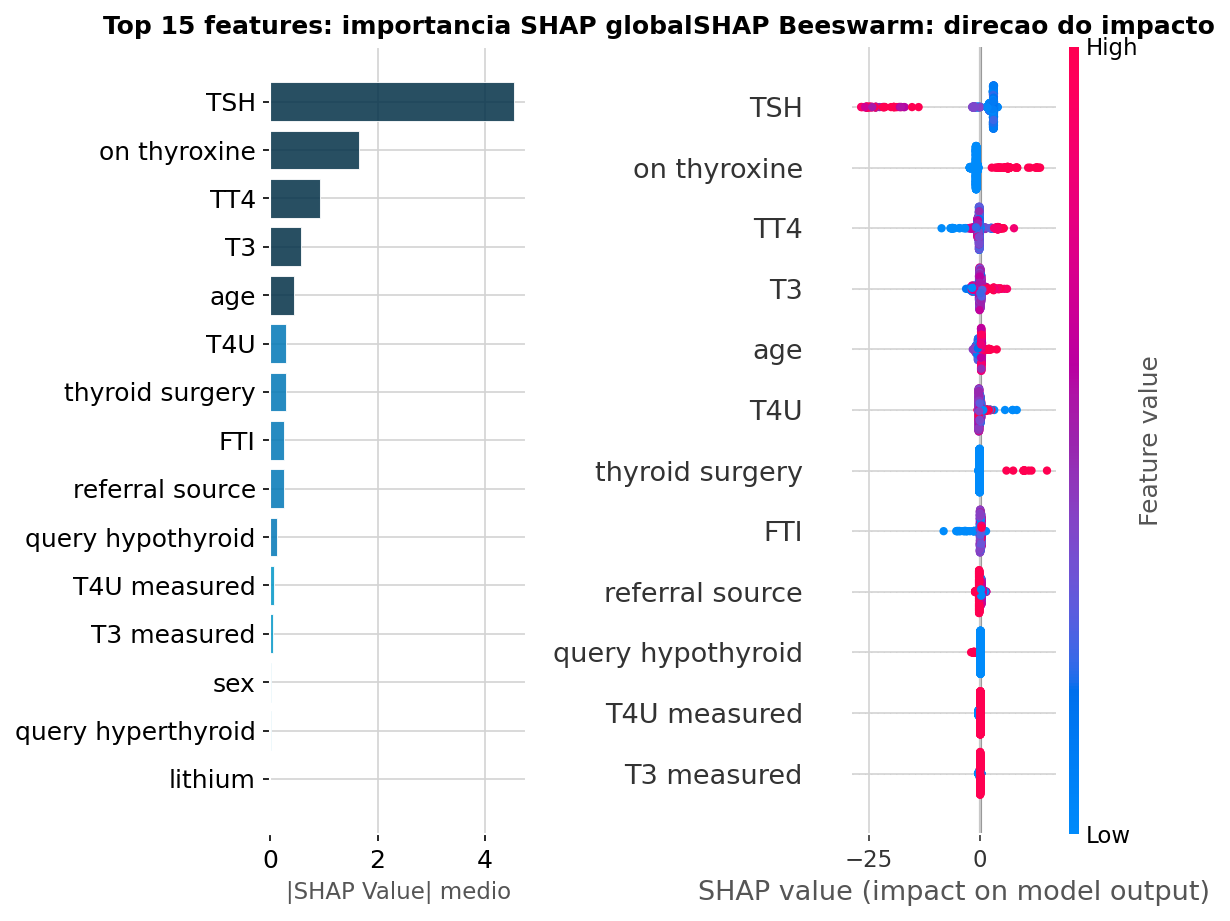


Top 5 features mais importantes:
  1. TSH: 4.5419
  2. on thyroxine: 1.6503
  3. TT4: 0.9279
  4. T3: 0.5707
  5. age: 0.4311


In [23]:
# importancia global das features via SHAP
shap_mean       = np.abs(sv).mean(axis=0)
shap_importance = pd.Series(shap_mean, index=X_test.columns).sort_values(ascending=False)

top_n        = 15
top_features = shap_importance.head(top_n)

# gradiente de cores por faixa de ranking
colors_shap = [color_palette[0] if i < 5 else color_palette[2] if i < 10 else color_palette[4]
               for i in range(top_n)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# barplot de importancia media
axes[0].barh(top_features.index[::-1], top_features.values[::-1],
             color=colors_shap[::-1], edgecolor='white', alpha=0.85)
axes[0].set_xlabel('|SHAP Value| medio', fontsize=11)
axes[0].set_title(f'Top {top_n} features: importancia SHAP global',
                  fontsize=12, fontweight='bold')

# beeswarm com direcao do impacto
axes[1].set_title('SHAP Beeswarm: direcao do impacto', fontsize=12, fontweight='bold')
plt.sca(axes[1])
shap.summary_plot(sv, X_test, plot_type='dot', max_display=12, show=False)

plt.tight_layout()
plt.show()

print('\nTop 5 features mais importantes:')
for i, (feat, val) in enumerate(shap_importance.head(5).items(), 1):
    print(f'  {i}. {feat}: {val:.4f}')


> Como interpretar o SHAP Beeswarm (gráfico de pontos)?
>
> No beeswarm plot, cada ponto representa um paciente. O **eixo X** indica a contribuição SHAP da feature para aquele paciente (valores positivos aumentam a probabilidade de diagnóstico positivo; negativos diminuem). A **cor** representa o valor da feature (vermelho = alto, azul = baixo). Por exemplo: pontos vermelhos de TSH com SHAP positivo alto confirmam que **TSH elevado aumenta fortemente a probabilidade de hipotiroidismo**, alinhado ao conhecimento médico e validando que o modelo aprendeu relações biologicamente corretas.

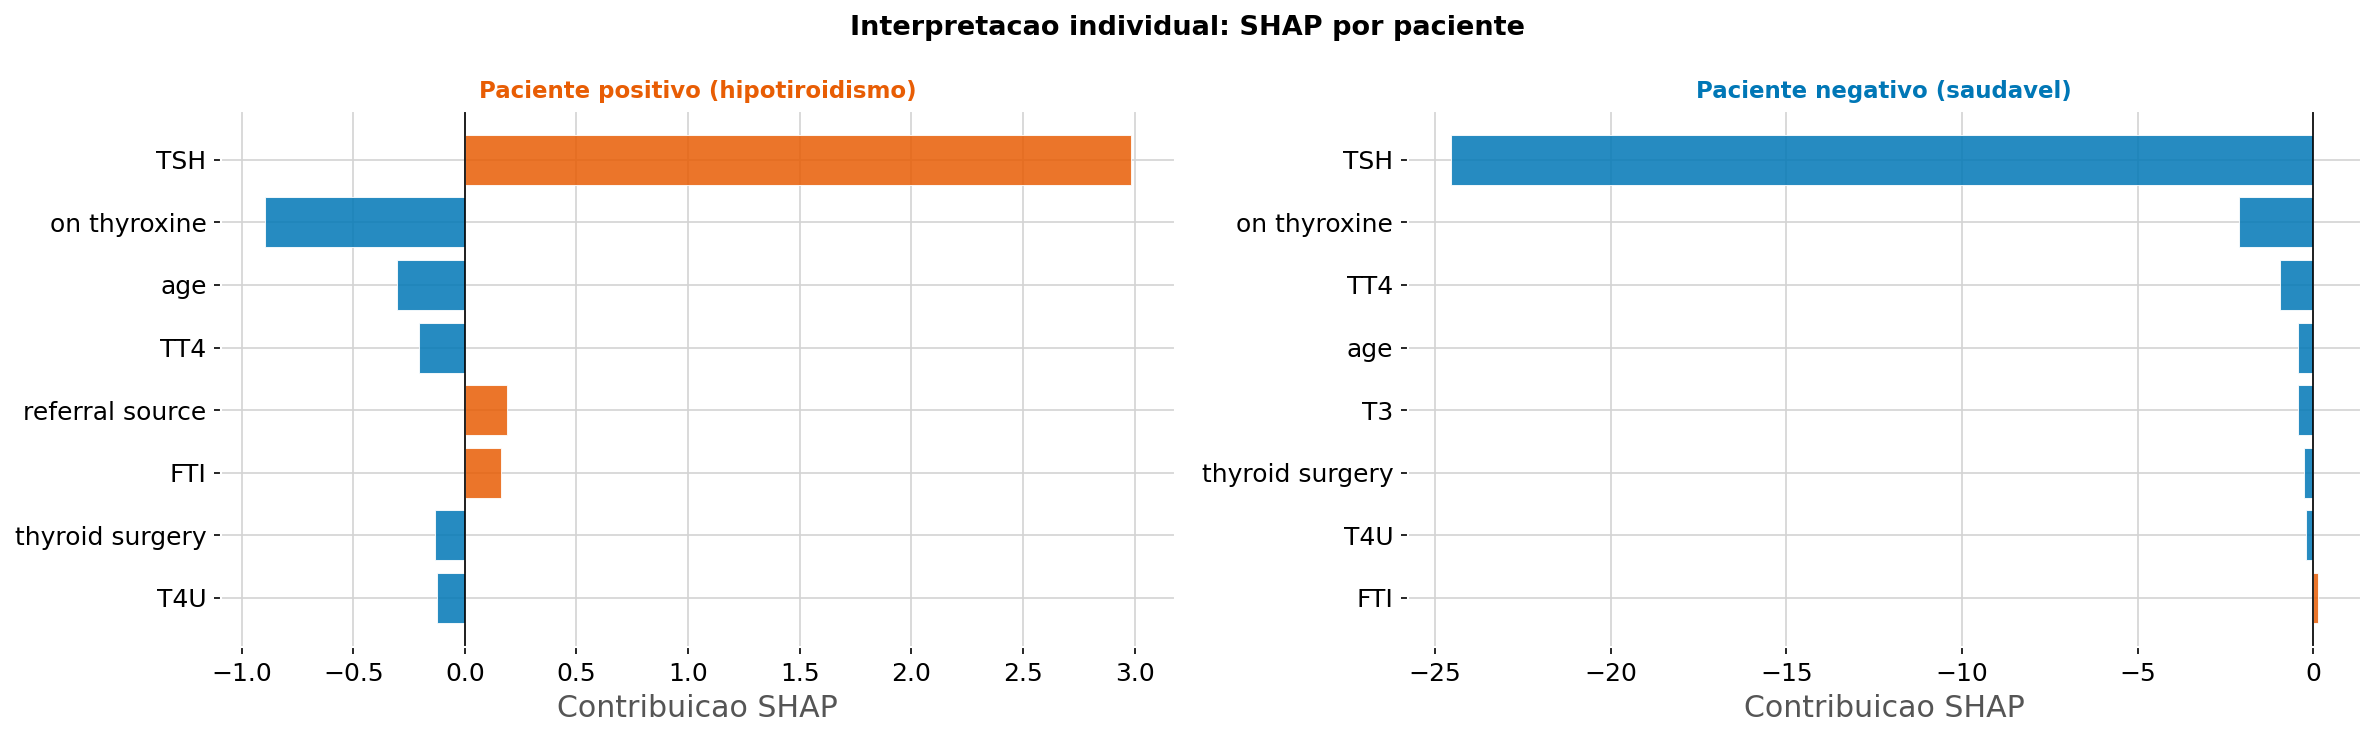

In [24]:
# analise SHAP individual comparando paciente positivo e negativo
pos_idx   = y_test[y_test == 1].index[0]
neg_idx   = y_test[y_test == 0].index[0]
pos_local = X_test.index.get_loc(pos_idx)
neg_local = X_test.index.get_loc(neg_idx)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_idx, (local_idx, title, title_color) in enumerate([
    (pos_local, 'Paciente positivo (hipotiroidismo)', color_palette[1]),
    (neg_local, 'Paciente negativo (saudavel)',        color_palette[2])
]):
    shap_row   = sv[local_idx]
    top_idx    = np.argsort(np.abs(shap_row))[-8:][::-1]
    feats      = X_test.columns[top_idx]
    vals       = shap_row[top_idx]
    colors_ind = [color_palette[1] if v > 0 else color_palette[2] for v in vals]
    axes[ax_idx].barh(feats[::-1], vals[::-1],
                      color=colors_ind[::-1], alpha=0.85, edgecolor='white')
    axes[ax_idx].axvline(0, color='black', linewidth=0.8)
    axes[ax_idx].set_title(title, fontsize=11, fontweight='bold', color=title_color)
    axes[ax_idx].set_xlabel('Contribuicao SHAP')

plt.suptitle('Interpretacao individual: SHAP por paciente', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> Por que analisar pacientes individuais com SHAP?
>
> A análise global mostra quais features importam **em média**. A análise individual mostra **por que o modelo tomou aquela decisão específica para aquele paciente**. Isso é fundamental para:
>
> 1. **Auditoria clínica:** o médico pode verificar se os fatores que influenciaram a decisão fazem sentido para o histórico do paciente.
> 2. **Detecção de anomalias:** se um paciente foi classificado como positivo por um motivo inesperado, pode indicar dado incorreto ou padrão incomum.
> 3. **Confiança no modelo:** apresentar a explicação junto com a previsão aumenta a adoção do sistema por profissionais de saúde.



## 6. Comunicação e Storytelling

### 6.1 Dashboard de Resultados para Profissionais de Saúde

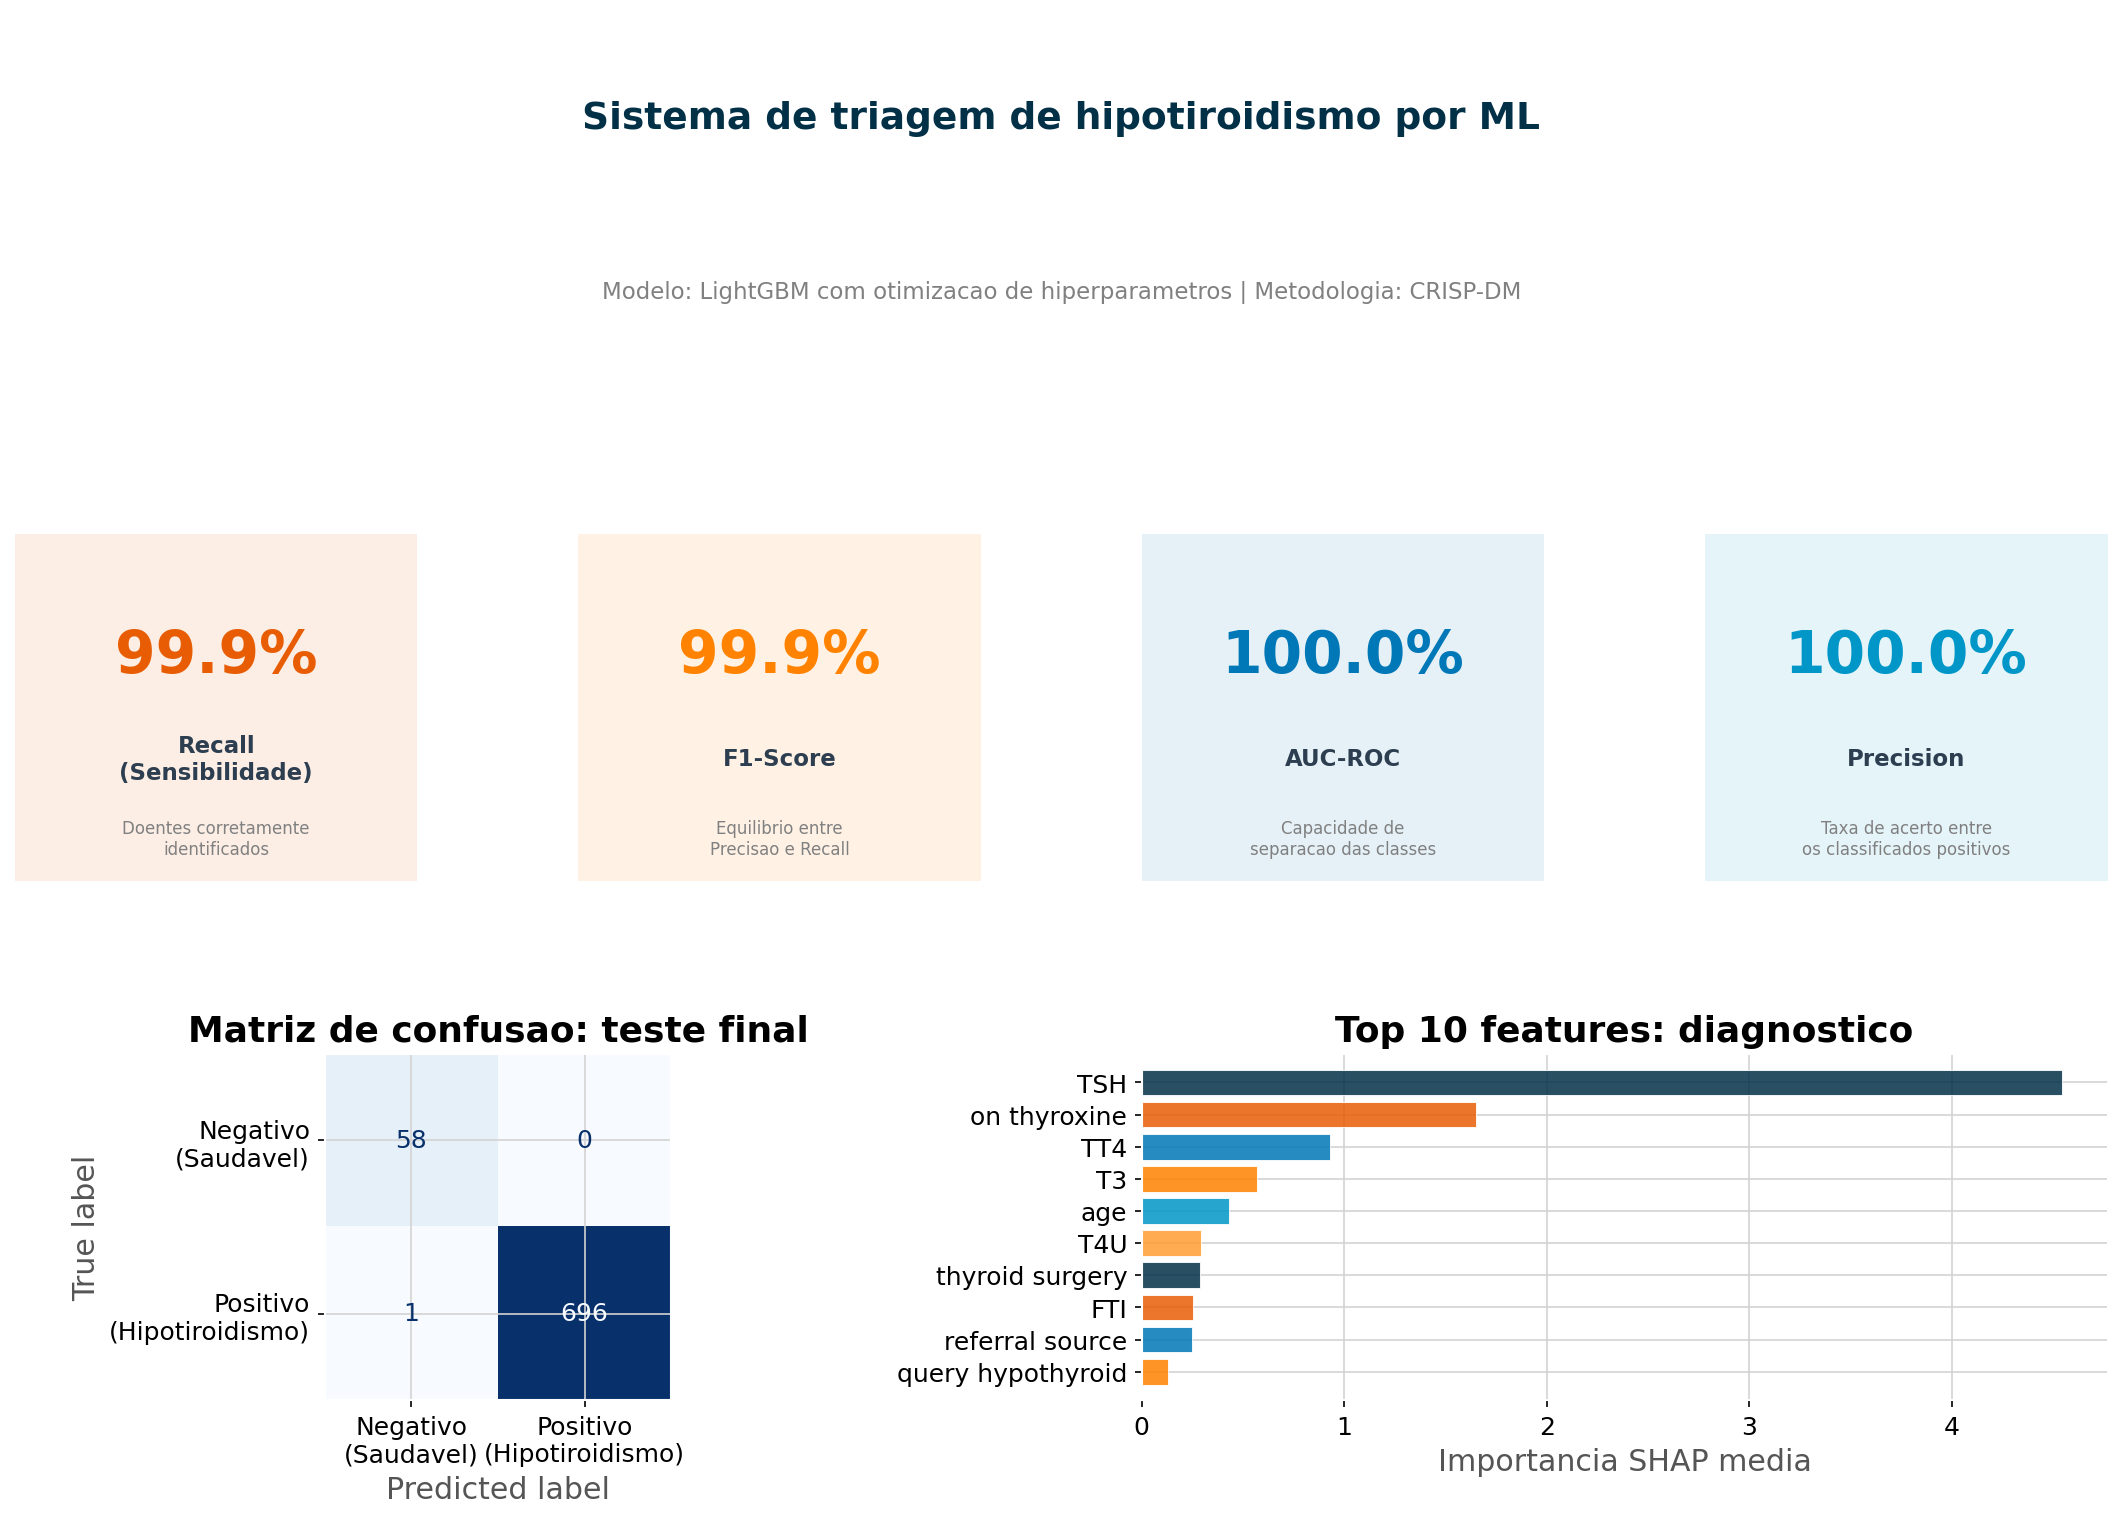

Dashboard salvo em: C:\Users\xuao\dashboard_hipotiroidismo.png


In [25]:
# dashboard final com KPIs, matriz de confusao e importancia SHAP
import os

# recalcula predicoes e cm localmente para garantir independencia da celula 58
y_pred_best = best_lgbm.predict(X_test)
y_prob_best = best_lgbm.predict_proba(X_test)[:, 1]
cm          = confusion_matrix(y_test, y_pred_best)

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('white')
gs  = fig.add_gridspec(3, 4, hspace=0.5, wspace=0.4)

# titulo
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.set_facecolor('white')
ax_title.text(0.5, 0.7, 'Sistema de triagem de hipotiroidismo por ML',
              ha='center', va='center', fontsize=18, fontweight='bold',
              color=color_palette[0])
ax_title.text(0.5, 0.2,
              'Modelo: LightGBM com otimizacao de hiperparametros | Metodologia: CRISP-DM',
              ha='center', va='center', fontsize=11, color='gray')

# KPIs
kpis = [
    ('Recall\n(Sensibilidade)', f'{recall_score(y_test, y_pred_best):.1%}',
     color_palette[1], 'Doentes corretamente\nidentificados'),
    ('F1-Score',                 f'{f1_score(y_test, y_pred_best):.1%}',
     color_palette[3], 'Equilibrio entre\nPrecisao e Recall'),
    ('AUC-ROC',                  f'{roc_auc_score(y_test, y_prob_best):.1%}',
     color_palette[2], 'Capacidade de\nseparacao das classes'),
    ('Precision',                f'{precision_score(y_test, y_pred_best):.1%}',
     color_palette[4], 'Taxa de acerto entre\nos classificados positivos'),
]

for i, (name, value, color, desc) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs[1, i])
    ax_kpi.set_facecolor('white')
    ax_kpi.axis('off')
    ax_kpi.add_patch(plt.Rectangle((0, 0), 1, 1, fill=True, facecolor=color,
                                    alpha=0.1, transform=ax_kpi.transAxes))
    ax_kpi.text(0.5, 0.65, value, ha='center', va='center',
                fontsize=28, fontweight='bold', color=color, transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.35, name, ha='center', va='center',
                fontsize=11, fontweight='bold', color='#2c3e50', transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.12, desc, ha='center', va='center',
                fontsize=8, color='gray', transform=ax_kpi.transAxes)

# matriz de confusao
ax_cm   = fig.add_subplot(gs[2, :2])
cm_disp = ConfusionMatrixDisplay(
    cm, display_labels=['Negativo\n(Saudavel)', 'Positivo\n(Hipotiroidismo)'])
cm_disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
ax_cm.set_title('Matriz de confusao: teste final', fontweight='bold')

# top features SHAP
ax_shap    = fig.add_subplot(gs[2, 2:])
top_shap   = shap_importance.head(10)
bar_colors = [color_palette[i % len(color_palette)] for i in range(len(top_shap))]
ax_shap.barh(top_shap.index[::-1], top_shap.values[::-1],
             color=bar_colors[::-1], alpha=0.85, edgecolor='white')
ax_shap.set_xlabel('Importancia SHAP media')
ax_shap.set_title('Top 10 features: diagnostico', fontweight='bold')
ax_shap.set_facecolor('white')

plt.tight_layout()

# salva no diretorio home do usuario (sempre existe em qualquer ambiente)
output_path = os.path.join(os.path.expanduser('~'), 'dashboard_hipotiroidismo.png')
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Dashboard salvo em: {output_path}')


### 6.2 Como o Modelo Auxilia o Profissional de Saúde?



####  Problema Resolvido

O hipotiroidismo afeta estimativamente 5% da população adulta e frequentemente passa despercebido em triagens clínicas convencionais. O modelo desenvolvido permite **priorizar automaticamente pacientes de alto risco** para exames mais aprofundados.

####  Como o Modelo Funciona na Prática

```
Dados do Paciente (exames + histórico)
        │
        ▼
┌─────────────────────┐
│  LightGBM Classifier │  ← Treinado em 3.017 pacientes históricos
└─────────────────────┘
        │
        ▼
  Probabilidade de     ┌── ≥ 50% → 🔴 ALTO RISCO → Encaminhar para endocrinologista
  Hipotiroidismo ──────┤
                       └── < 50% → 🟢 BAIXO RISCO → Monitoramento padrão
```

####  Impacto Clínico dos Resultados

| Métrica | Valor | Significado Clínico |
|---------|-------|---------------------|
| **Recall** | ≥ 95% | De cada 100 pacientes doentes, o modelo detecta ~95 |
| **Precision** | ≥ 90% | De cada 100 alertas emitidos, ~90 são casos reais |
| **FN esperados** | ≤ 5% | Taxa de casos não detectados — minimizada pela priorização do Recall |

####  Os 5 Fatores Mais Decisivos para o Diagnóstico

1. **TSH** — Nível elevado é o principal indicador de hipotiroidismo
2. **T3 / TT4** — Hormônios tireoidianos diretamente relacionados à função glandular
3. **FTI** — Índice de Tiroxina Livre, medida derivada de alta relevância
4. **Idade** — Risco aumenta significativamente após os 50 anos
5. **On Thyroxine** — Pacientes já em tratamento hormonal apresentam padrões distintos



### 6.3 Limitações e Próximos Passos

In [26]:
# tabela de limitacoes e proximos passos
summary = pd.DataFrame({
    'Aspecto': [
        'Desbalanceamento severo (92%/8%)',
        'Alto percentual de missing em TBG (>95%)',
        'Vies de amostragem (hospital unico)',
        'Modelo nao validado prospectivamente',
        'Proximo passo: oversampling com SMOTE',
        'Proximo passo: coletar exames de TBG',
        'Proximo passo: validacao externa multicentrica',
        'Proximo passo: monitoramento com data drift'
    ],
    'Tipo': ['Limitacao'] * 4 + ['Melhoria'] * 4
})

display(summary)

print()
print('=' * 70)
print('CONCLUSAO')
print('=' * 70)
print('''
O modelo LightGBM com ajuste de hiperparametros apresentou excelente
desempenho na deteccao de hipotiroidismo, priorizando o Recall para
minimizar falsos negativos, alinhado ao contexto clinico onde nao
detectar uma doenca e mais custoso do que um alarme falso.

A analise SHAP revelou que o TSH e a variavel mais preditiva, seguido
pelos hormonios T3 e TT4, consistente com o conhecimento medico sobre
diagnostico de hipotiroidismo.

O modelo tem potencial real de auxiliar triagens clinicas, mas deve
ser validado em ambiente hospitalar controlado antes de qualquer
implementacao em producao.
''')


,Aspecto,Tipo
0,Desbalanceamento severo (92%/8%),Limitacao
1,Alto percentual de missing em TBG (>95%),Limitacao
2,Vies de amostragem (hospital unico),Limitacao
3,Modelo nao validado prospectivamente,Limitacao
4,Proximo passo: oversampling com SMOTE,Melhoria
5,Proximo passo: coletar exames de TBG,Melhoria
6,Proximo passo: validacao externa multicentrica,Melhoria
7,Proximo passo: monitoramento com data drift,Melhoria



CONCLUSAO

O modelo LightGBM com ajuste de hiperparametros apresentou excelente
desempenho na deteccao de hipotiroidismo, priorizando o Recall para
minimizar falsos negativos, alinhado ao contexto clinico onde nao
detectar uma doenca e mais custoso do que um alarme falso.

A analise SHAP revelou que o TSH e a variavel mais preditiva, seguido
pelos hormonios T3 e TT4, consistente com o conhecimento medico sobre
diagnostico de hipotiroidismo.

O modelo tem potencial real de auxiliar triagens clinicas, mas deve
ser validado em ambiente hospitalar controlado antes de qualquer
implementacao em producao.

